Scikit learn provides many heloer functions to donwload popualr datasets. MNIST is one of them
the following code fetchest the MNIST dataset:

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

Datasets loaded by scikitlearn generally have a simiilar dicitonary structure, including the folloring:
A DESCR key describing the dataset
A data key containing an array with one row per instance and one column per feature
A traget key containing an array with the labels


In [2]:
#lets look at these arrays:
X, y = mnist["data"], mnist["target"]
X.shape


(70000, 784)

In [3]:
y.shape

(70000,)

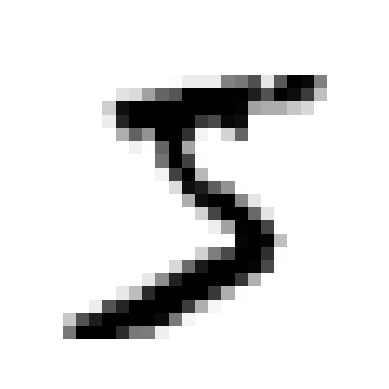

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = X[0] #give me the first image(row 
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [5]:
y[0]

'5'

In [6]:
import numpy as np
y = y.astype(np.uint8)

But wait! You should always create a test set and set it aside before inspecting the data
closely. The MNIST dataset is actually already split into a training set (the first 60,000
images) and a test set (the last 10,000 images):


In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Training a Binary Classifier
Let’s simplify the problem for now and only try to identify one digit—for example,
the number 5. This “5-detector” will be an example of a binary classifier, capable of
distinguishing between just two classes, 5 and not-5. Let’s create the target vectors for
this classification task:

In [8]:
y_train_5 = (y_train == 5) # True for all %s, False for all other digits
y_test_5 = (y_test == 5)

In [9]:
print(y_train_5[:10])  # should show mix of True and False
print(y_train_5.sum()) # should sh

[ True False False False False False False False False False]
5421


In [10]:
#sgd models learns one image at a time indeas of all at once
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [11]:
sgd_clf.predict([some_digit])
#the classifier guesess that this image represnt a 5 (True). Looks like it guessed right in this particular cae,

array([ True])

Measuring Accuracy using cross validation
A good way to evaulate a model is to use cross-validation, just as you did in chapter 2.

Implementing cross-validation

Ocassionally you will need more control over the cross-validation process than what Scikit-Learn provides off the shelf. In these cases, you can implement cross-validation yourself. The following code does roughly  the same thing as Scikit-Learns corss_val_score() function, and ti prints the same result:


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone # creates a fresh copy of the classifier with the same hyperparameteers but not learned weights

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True) #n_splits=3 divides data into 3 equal folds

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred)) # gives the accuracy

0.9669
0.91625
0.96785


In [13]:
#this  also does the same thing of finding the accuracy as in the above code but in the few lines
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy") #it autmoatically splits into 60 10 for train and test

array([0.95035, 0.96035, 0.9604 ])

its a base class from skleanr 
think of it like a template that gives your custom class all the basic sklearn behavios for free

BaseEstimaor is like a house blueprint

1. What are params?

Params = Parameters of a model

These are the settings you give when creating a model.

Example:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=5)

👉 Here:

n_estimators=100 → number of trees
max_depth=5 → how deep each tree can go

These are called parameters (params).

📦 2. get_params()

This function shows all parameters of the model.

Example:
model.get_params()
Output (simplified):
{
 'n_estimators': 100,
 'max_depth': 5,
 'random_state': None,
 ...
}

👉 Think of it like:

“Tell me all your settings.”

⚙️ 3. set_params()

This function changes parameters AFTER creating the model.

Example:
model.set_params(n_estimators=200)

Now:

model.get_params()['n_estimators']

👉 Output:

200
🧠 Simple Analogy

Think of a model like a car 🚗

Concept	Meaning
params	Car settings (speed limit, engine type)
get_params()	Check current settings
set_params()	Change settings
🔥 Why this matters (important for you)
1. Used in Grid Search / Tuning
from sklearn.model_selection import GridSearchCV

It uses:

get_params() → to see what can be tuned
set_params() → to try different values
2. Cleaner than recreating model

Instead of:

model = RandomForestRegressor(n_estimators=200)

You can just:

model.set_params(n_estimators=200)
💡 One thing students often miss

👉 set_params() does NOT retrain the model

You still need:

model.fit(X, y)
🚀 Final understanding
params → configuration of model
get_params() → view configuration
set_params() → modify configuration

In [14]:
#basestimator gives access to various sklearn behavuours for free
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool) 
        #len(x), 1 = creates array with 20000 rows 1 column
        #dtype=bool #fills with False instead of 0

In [15]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

In [16]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [17]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [18]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

The confusion matrix gives you a lot of information, but someimtes you may prefer a more concise metric. An interesting one to look at is the accuracy of the positive predictions; this is called the precision of classifear
and we can do it using the precision_score.

prediction_score => when the model sys yes is it actually yes
recall_score => out of all yes how many did it find
f1_score => combines both 

Precision = how careful the model is
Recall    = how thorough the model is

F1 = balance between careful and thorough

High F1 → model is BOTH careful and thorough ✅
Low F1  → model is bad at one or both ❌
1.0 -> max (good)
0.0 -> low(bad)

In [19]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) #when the model says yes is it actually yes?


0.8370879772350012

In [20]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [21]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)


0.7325171197343847

In [24]:
y_scores = sgd_clf.decision_function([some_digit]) #decison_function = gets teh raw score instead 
y_scores

array([2164.22030239])

In [28]:
#Note: lower threshold = higher recall
# higher threshold = higher precision
threshold = 0
y_some_digit_pred = (y_scores > threshold)

y_some_digit_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [29]:
threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False, False, False, ...,  True, False, False], shape=(60000,))

How do you decide whiv threshold to use? First, use the cross_val_predict() function to ge tht escores of all istances in the training set, but this time specify that you want to return decision scores instead of  predicitons

In [31]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
#it returns the decision score
#decision_score = it gives the raw score of how confident the model is that the image is a 5.

with these scores, use the precision_recall_curve() function to compute precision and recall for all possible threshold

In [32]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

finally use Matplotlib to plot precision and recall as functions of the threshold value

In [38]:
def plot_precision_recall_vs_threshold(precision, recalls, thresholds):
    plt.plot(thresholds, precision[:-1], "b--", label="Precision") #[:-1] means remove the last vlaue
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    [...]

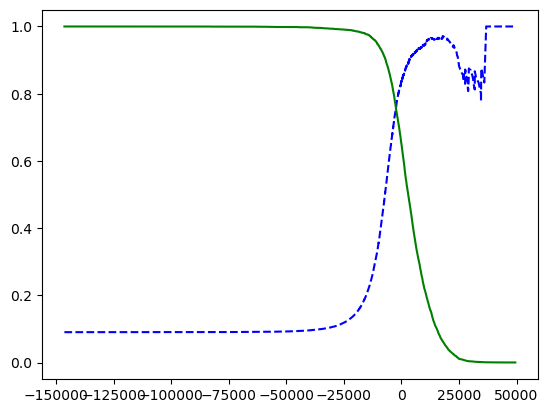

In [39]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

You can see that precision really starts to fall sharply around 80% recall. You will
probably want to select a precision/recall trade-off just before that drop—for exam‐
ple, at around 60% recall. But of course, the choice depends on your project.
Suppose you decide to aim for 90% precision. You look up the first plot and find that
you need to use a threshold of about 8,000. To be more precise you can search for the
lowest threshold that gives you at least 90% precision (np.argmax() will give you the
first index of the maximum value, which in this case means the first True value):


In [41]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

to make predictions (on training set for now), instead of calling the classifiers predict() method you can run this code:

In [44]:
y_train_pred_90 = (y_scores >= threshold_90_precision)


In [45]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [46]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

In [48]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fplr, tpr, linewidth = 2, label=label)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fplr, tpr, linewidth = 2, label=label)
    plt.plot([0, 1], [0,1], 'k--')
    # [0,1] = x goes from 0 to 1
    #[0,1]= y goes from o to 1
    # 'k--' means black, -- means dashed line
    [...]

plt_roc_curve(fplr, tpe)
plt.show()    [...]

plt_roc_curve(fplr, tpe)
plt.show()

NameError: name 'plt_roc_curve' is not defined